# Zadanie 08 - `Uczenie ze wzmocnieniem: zastosowanie modeli uczenia ze wzmocnieniem w optymalizacji procedur medycznych`

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)


## 1. Definicja środowiska (MDP) dla wariantu 2

Modelujemy uproszczony proces decyzyjny:
- Stany: Normoglycemia (N), Hyperglycemia (H), SevereHyperglycemia (S)
- Akcje: NoTreatment (NT), OralMed (OM), Insulin (IN)
- Nagrody: +10 za przejście do N, -6 za przejście do S
- Koszty: NT=0, OM=-1.5, IN=-3


In [9]:
from dataclasses import dataclass

STATES = ["Normoglycemia", "Hyperglycemia", "SevereHyperglycemia"]
ACTIONS = ["NoTreatment", "OralMed", "Insulin"]

S = {name: i for i, name in enumerate(STATES)}
A = {name: i for i, name in enumerate(ACTIONS)}

@dataclass
class StepResult:
    next_state: int
    reward: float
    done: bool

class DiabetesEnv:
    def __init__(self, max_steps=20):
        self.max_steps = max_steps
        self.cost = {
            A["NoTreatment"]: 0.0,
            A["OralMed"]: 1.5,
            A["Insulin"]: 3.0,
        }
        self.reset()

    def reset(self, start_state="Hyperglycemia"):
        self.state = S[start_state]
        self.t = 0
        return self.state

    def step(self, action) -> StepResult:
        self.t += 1
        s = self.state

        # Definicje przejść
        # Dla stanu H (Hyperglycemia)
        if s == S["Hyperglycemia"]:
            if action == A["NoTreatment"]:
                probs = [(S["Hyperglycemia"], 0.70), (S["SevereHyperglycemia"], 0.25), (S["Normoglycemia"], 0.05)]
                base_reward = 0
            elif action == A["OralMed"]:
                probs = [(S["Normoglycemia"], 0.40), (S["Hyperglycemia"], 0.50), (S["SevereHyperglycemia"], 0.10)]
                base_reward = 0
            else:  # Insulin
                probs = [(S["Normoglycemia"], 0.65), (S["Hyperglycemia"], 0.30), (S["SevereHyperglycemia"], 0.05)]
                base_reward = 0

        # Dla stanu S (SevereHyperglycemia)
        elif s == S["SevereHyperglycemia"]:
            if action == A["NoTreatment"]:
                probs = [(S["SevereHyperglycemia"], 0.75), (S["Hyperglycemia"], 0.20), (S["Normoglycemia"], 0.05)]
                base_reward = 0
            elif action == A["OralMed"]:
                probs = [(S["Hyperglycemia"], 0.60), (S["SevereHyperglycemia"], 0.35), (S["Normoglycemia"], 0.05)]
                base_reward = 0
            else:  # Insulin
                probs = [(S["Hyperglycemia"], 0.50), (S["Normoglycemia"], 0.40), (S["SevereHyperglycemia"], 0.10)]
                base_reward = 0

        # Dla stanu N (Normoglycemia)
        else:  # s == S["Normoglycemia"]
            if action == A["NoTreatment"]:
                probs = [(S["Normoglycemia"], 0.85), (S["Hyperglycemia"], 0.14), (S["SevereHyperglycemia"], 0.01)]
                base_reward = 0
            elif action == A["OralMed"]:
                probs = [(S["Normoglycemia"], 0.88), (S["Hyperglycemia"], 0.12)]
                base_reward = 0
            else:  # Insulin
                probs = [(S["Normoglycemia"], 0.86), (S["Hyperglycemia"], 0.13), (S["SevereHyperglycemia"], 0.01)]
                base_reward = 0

        # Losowanie następnego stanu
        r = np.random.rand()
        cum = 0
        next_state = s
        for ns, p in probs:
            cum += p
            if r <= cum:
                next_state = ns
                break

        # Nagroda zależna od osiągniętego stanu
        state_reward = 0
        if next_state == S["Normoglycemia"]:
            state_reward = 10
        elif next_state == S["SevereHyperglycemia"]:
            state_reward = -6
        else:
            state_reward = 0

        reward = base_reward + state_reward - self.cost[action]

        self.state = next_state
        done = self.t >= self.max_steps
        return StepResult(next_state, reward, done)

env = DiabetesEnv()


In [7]:
state = env.reset()
for i in range(5):
    res = env.step(A["OralMed"])
    print(f"krok {i+1}: {STATES[state]} → {STATES[res.next_state]}, nagroda={res.reward:.2f}")
    state = res.next_state


krok 1: Hyperglycemia → Normoglycemia, nagroda=8.50
krok 2: Normoglycemia → Hyperglycemia, nagroda=-1.50
krok 3: Hyperglycemia → Hyperglycemia, nagroda=-1.50
krok 4: Hyperglycemia → Hyperglycemia, nagroda=-1.50
krok 5: Hyperglycemia → Normoglycemia, nagroda=8.50


## 2. Algorytm Q-learning

Aktualizacja:
Q(s,a) ← Q(s,a) + α [ r + γ max Q(s′,a′) − Q(s,a) ]

Stosujemy strategię eksploracji ε-greedy.


In [8]:
def epsilon_greedy(Q, state, eps):
    if np.random.rand() < eps:
        return np.random.randint(Q.shape[1])
    return np.argmax(Q[state])


def q_learning(env, episodes=2000, alpha=0.1, gamma=0.95, epsilon=0.3):
    Q = np.zeros((len(STATES), len(ACTIONS)))
    rewards = []

    for ep in range(episodes):
        s = env.reset()
        total = 0
        while True:
            a = epsilon_greedy(Q, s, epsilon)
            res = env.step(a)
            Q[s, a] += alpha * (res.reward + gamma * np.max(Q[res.next_state]) - Q[s, a])
            total += res.reward
            s = res.next_state
            if res.done:
                break
        rewards.append(total)

    return Q, rewards


Q, rewards = q_learning(env)


## 3. Deep Reinforcement Learning (DQN) — wersja TensorFlow/Keras

W DQN aproksymujemy funkcję Q(s,a) siecią neuronową:
Q(s,a; θ) ≈ Q*(s,a)

Aby stabilizować uczenie stosujemy:
- **Replay Buffer** (uczenie na losowych mini-batchach z pamięci)
- **Target Network** (oddzielna sieć do wyznaczania celu TD)


### 3.1 Kodowanie stanu (one-hot)

Stany kliniczne kodujemy jako wektory one-hot:
- Normoglycemia  → [1, 0, 0]
- Hyperglycemia   → [0, 1, 0]
- SevereHyperglycemia → [0, 0, 1]


In [12]:
def encode_state(state_idx, n_states):
    vec = np.zeros(n_states, dtype=np.float32)
    vec[state_idx] = 1.0
    return vec


### 3.2 Replay Buffer


In [13]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buffer.append((s, a, r, s2, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        return s.astype(np.float32), a.astype(np.int32), r.astype(np.float32), s2.astype(np.float32), d.astype(np.float32)

    def __len__(self):
        return len(self.buffer)


### 3.3 Model Q (sieć neuronowa Keras)


In [14]:
def build_dqn(state_dim, action_dim):
    model = keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(action_dim)  # wartości Q dla każdej akcji
    ])
    return model


### 3.4 Funkcje pomocnicze: wybór akcji i aktualizacja target network


In [15]:
def epsilon_greedy_action(q_model, state_vec, epsilon, action_dim):
    if np.random.rand() < epsilon:
        return np.random.randint(action_dim)
    q = q_model(np.expand_dims(state_vec, axis=0), training=False).numpy()[0]
    return int(np.argmax(q))

def update_target_network(q_model, target_model):
    target_model.set_weights(q_model.get_weights())


### 3.5 Trening DQN (z target network)

Cel TD z target network:
y = r + γ * max_a' Q_target(s', a')  (jeśli done=0)
y = r                               (jeśli done=1)


In [17]:
def dqn_training(env: DiabetesEnv, episodes=1200, gamma=0.95, batch_size=64, target_update=50):
    n_states = len(STATES)
    n_actions = len(ACTIONS)

    q_net = build_dqn(state_dim=n_states, action_dim=n_actions)
    target_net = build_dqn(state_dim=n_states, action_dim=n_actions)
    update_target_network(q_net, target_net)

    optimizer = keras.optimizers.Adam(learning_rate=1e-3)
    loss_fn = keras.losses.Huber() # stabilniejsza niż MSE

    buffer = ReplayBuffer(capacity=10000)

    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.995

    warmup_steps = 200   # zanim zaczniemy trenować, zbierz trochę doświadczeń

    episode_rewards = []
    loss_history = []

    @tf.function
    def train_step(states_b, actions_b, rewards_b, next_states_b, dones_b):
        # target: r + gamma * max_a Q_target(s', a') * (1-done)
        next_q = target_net(next_states_b, training=False)
        max_next_q = tf.reduce_max(next_q, axis=1)
        targets = rewards_b + gamma * max_next_q * (1.0 - dones_b)

        with tf.GradientTape() as tape:
            q_values = q_net(states_b, training=True)
            idx = tf.stack([tf.range(tf.shape(actions_b)[0]), actions_b], axis=1)
            q_sa = tf.gather_nd(q_values, idx)
            loss = loss_fn(targets, q_sa)

        grads = tape.gradient(loss, q_net.trainable_variables)
        optimizer.apply_gradients(zip(grads, q_net.trainable_variables))
        return loss

    step_count = 0
    for ep in range(episodes):
        s = env.reset()
        s_vec = encode_state(s, n_states)
        total_reward = 0.0

        while True:
            a = epsilon_greedy_action(q_net, s_vec, epsilon, n_actions)
            step_result = env.step(a)

            done = step_result.done

            s2_vec = encode_state(step_result.next_state, n_states)
            buffer.push(s_vec, a, step_result.reward, s2_vec, float(done))


            s2 = step_result.next_state
            r = step_result.reward

            step_count += 1

            s_vec = s2_vec
            total_reward += step_result.reward

            # Trening (trening po rozgrzewce i gdy mamy batch)
            if step_count > warmup_steps and len(buffer) >= batch_size:
                sb, ab, rb, s2b, db = buffer.sample(batch_size)

                loss = train_step(
                    tf.convert_to_tensor(sb),
                    tf.convert_to_tensor(ab),
                    tf.convert_to_tensor(rb),
                    tf.convert_to_tensor(s2b),
                    tf.convert_to_tensor(db)
                )
                loss_history.append(float(loss.numpy()))

            if done:
                break

        # epsilon decay
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # Aktualizacja target network
        if (ep + 1) % target_update == 0:
            update_target_network(q_net, target_net)

        episode_rewards.append(total_reward)

        if (ep+1) % 100 == 0:
            print(f"Epizod {ep+1}/{episodes} | reward={total_reward:.2f} | epsilon={epsilon:.3f} | buffer={len(buffer)}")
            # print(f"Epizod {ep+1}/{episodes}, średnia nagroda (ostatnie 50): {np.mean(episode_rewards[-50:]):.2f}")

    return q_net, episode_rewards


## 4. Uruchomienie i analiza (Q-learning i DQN)

=== Q-learning ===
Polityka Q-learning: {'Normoglycemia': 'OralMed', 'Hyperglycemia': 'Insulin', 'SevereHyperglycemia': 'Insulin'}


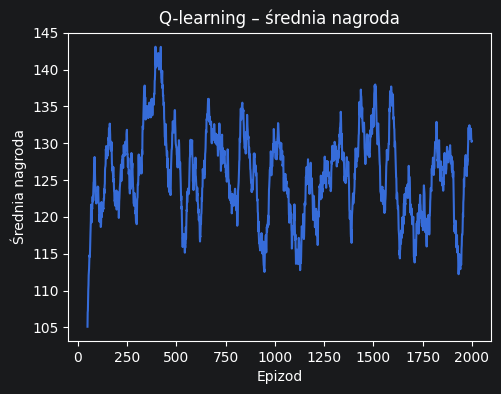

In [27]:
if __name__ == "__main__":
    env = DiabetesEnv()
    n_states = len(STATES)

    # ---- Q-learning ----
    print("=== Q-learning ===")
    Q_table, rewards_q = q_learning(env, episodes=2000)

    # odczyt polityki decyzyjnej
    policy_q = {STATES[s]: ACTIONS[np.argmax(Q_table[s])] for s in range(n_states)}
    print("Polityka Q-learning:", policy_q)

    # Krzywa uczenia
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(pd.Series(rewards_q).rolling(50).mean())
    plt.title("Q-learning – średnia nagroda")
    plt.xlabel("Epizod")
    plt.ylabel("Średnia nagroda")
    plt.show()



=== DQN ===
Epizod 100/1200 | reward=159.00 | epsilon=0.606 | buffer=2000
Epizod 200/1200 | reward=147.50 | epsilon=0.367 | buffer=4000
Epizod 300/1200 | reward=82.50 | epsilon=0.222 | buffer=6000
Epizod 400/1200 | reward=152.00 | epsilon=0.135 | buffer=8000
Epizod 500/1200 | reward=113.00 | epsilon=0.082 | buffer=10000
Epizod 600/1200 | reward=74.00 | epsilon=0.050 | buffer=10000
Epizod 700/1200 | reward=171.00 | epsilon=0.050 | buffer=10000
Epizod 800/1200 | reward=171.00 | epsilon=0.050 | buffer=10000
Epizod 900/1200 | reward=156.50 | epsilon=0.050 | buffer=10000
Epizod 1000/1200 | reward=171.00 | epsilon=0.050 | buffer=10000
Epizod 1100/1200 | reward=122.00 | epsilon=0.050 | buffer=10000
Epizod 1200/1200 | reward=155.00 | epsilon=0.050 | buffer=10000
Polityka DQN: {'Normoglycemia': 'NoTreatment', 'Hyperglycemia': 'Insulin', 'SevereHyperglycemia': 'Insulin'}


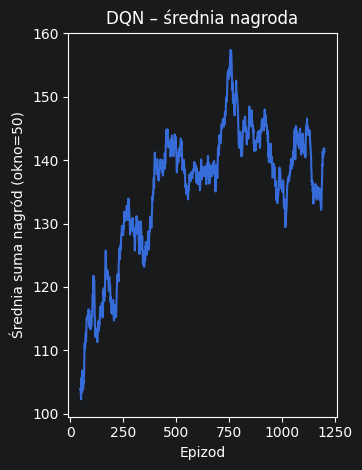

In [24]:
    # ---- DQN ----
    print("\n=== DQN ===")
    env_dqn = DiabetesEnv()  # nowa instancja
    q_net, rewards_dqn = dqn_training(env_dqn, episodes=1200)
    policy_dqn = {}
    for i, s_name in enumerate(STATES):
        vec = encode_state(i, n_states)
        qv = q_net(np.expand_dims(vec, axis=0), training=False).numpy()[0]
        policy_dqn[s_name] = ACTIONS[np.argmax(qv)]
    print("Polityka DQN:", policy_dqn)

    # Krzywa uczenia DQN
    plt.subplot(1,2,2)
    plt.plot(pd.Series(rewards_dqn).rolling(50).mean())
    plt.title("DQN – średnia nagroda")
    plt.xlabel("Epizod")
    plt.ylabel("Średnia suma nagród (okno=50)")
    plt.tight_layout()
    plt.show()


In [25]:
    def dqn_policy_tf(q_model):
        pol = {}
        for i, s_name in enumerate(STATES):
            v = encode_state(i, n_states)
            q = q_model(np.expand_dims(v, axis=0), training=False).numpy()[0]
            pol[s_name] = ACTIONS[int(np.argmax(q))]
        return pol

    dqn_policy_tf(q_net)


{'Normoglycemia': 'NoTreatment',
 'Hyperglycemia': 'Insulin',
 'SevereHyperglycemia': 'Insulin'}

## 5. Explainable Reinforcement Learning (XRL)

Uczenie ze wzmocnieniem, a szczególnie Deep Reinforcement Learning (DQN),
często jest krytykowane za brak interpretowalności („czarna skrzynka”).

W medycynie **wyjaśnialność decyzji** jest kluczowa, ponieważ:
- decyzje wpływają na zdrowie i życie pacjenta,
- lekarz musi rozumieć *dlaczego* system rekomenduje daną akcję,
- wymagane są audytowalność i zgodność etyczna.

W tej sekcji pokazujemy **proste, dydaktyczne metody wyjaśniania decyzji DQN**.


### 5.1 Wyjaśnienie typu: „dlaczego ta akcja?”

Najprostsze i bardzo skuteczne wyjaśnienie polega na:
1. obliczeniu wartości Q dla wszystkich akcji,
2. pokazaniu, że wybrana akcja ma najwyższą wartość oczekiwaną.


In [28]:
    def explain_action(q_model, state_idx):
        state_vec = encode_state(state_idx, n_states)
        q_values = q_model(np.expand_dims(state_vec, axis=0), training=False).numpy()[0]

        explanation = pd.DataFrame({
            "akcja": ACTIONS,
            "Q(s,a)": q_values
        }).sort_values("Q(s,a)", ascending=False)

        return explanation, q_values


In [30]:
    print("\n=== Explainable RL ===")
    # 5.1 Analiza wartości Q dla stanu Hyperglycemia
    state_test = "Hyperglycemia"
    state_idx = S[state_test]

    explanation, q_values = explain_action(q_net, state_idx)
    print(explanation)



=== Explainable RL ===
         akcja      Q(s,a)
2      Insulin  135.088318
1      OralMed  127.826469
0  NoTreatment  124.917938


#### Interpretacja kliniczna

Przykładowe wyjaśnienie:
- Agent wybrał akcję **Insulin**, ponieważ jej wartość Q(s,a) jest najwyższa.
- Oznacza to, że w długim horyzoncie czasowym ta decyzja:
  - maksymalizuje poprawę stanu,
  - minimalizuje ryzyko pogorszenia,
  - uwzględnia koszt terapii.

Takie wyjaśnienie można przedstawić lekarzowi w formie tabeli lub wykresu.


### 5.2 Wyjaśnienie kontrfaktyczne: „co by było, gdyby…?”

Wyjaśnienie kontrfaktyczne odpowiada na pytanie:
> „Co by się stało, gdyby agent wybrał inną akcję?”

Porównujemy wartości Q dla alternatywnych decyzji.


In [32]:
    def counterfactual_explanation(q_model, state_idx):
        df, _ = explain_action(q_model, state_idx)
        best = df.iloc[0]
        second = df.iloc[1]

        diff = best["Q(s,a)"] - second["Q(s,a)"]

        return {
            "najlepsza_akcja": best["akcja"],
            "alternatywa": second["akcja"],
            "roznica_Q": float(diff)
        }


In [34]:
    # 5.2 Wyjaśnienie kontrfaktyczne – różnica względem drugiej najlepszej akcji
    counterfactual_explanation(q_net, state_idx)


{'najlepsza_akcja': 'Insulin',
 'alternatywa': 'OralMed',
 'roznica_Q': 7.261848449707031}

### 5.3 Wrażliwość decyzji na zmianę nagrody (Explainability globalna)

W RL decyzje są silnie zależne od funkcji nagrody.
Możemy badać:
- jak zmiana kosztów terapii wpływa na politykę,
- czy model preferuje agresywne leczenie zbyt często.


In [36]:
    # 5.3 Wrażliwość na koszt insuliny – zmiana polityki
    print("\nAnaliza wrażliwości na koszt insuliny (zmiana z -3 na -5):")
    env_high_cost = DiabetesEnv()
    env_high_cost.cost[A["Insulin"]] = 5.0  # zwiększamy koszt insuliny
    q_net2, _ = dqn_training(env_high_cost, episodes=500)  # krótki trening
    policy_high_cost = {}

    for i, s_name in enumerate(STATES):
        vec = encode_state(i, len(STATES))
        qv = q_net2(np.expand_dims(vec, axis=0), training=False).numpy()[0]
        policy_high_cost[s_name] = ACTIONS[np.argmax(qv)]
    print(f"Nowa polityka: {policy_high_cost}")
    print("(Zmiana kosztu wpłynęła na decyzje w stanach wysokiego ryzyka)")



Analiza wrażliwości na koszt insuliny (zmiana z -3 na -5):
Epizod 100/500 | reward=144.00 | epsilon=0.606 | buffer=2000
Epizod 200/500 | reward=142.00 | epsilon=0.367 | buffer=4000
Epizod 300/500 | reward=124.50 | epsilon=0.222 | buffer=6000
Epizod 400/500 | reward=90.00 | epsilon=0.135 | buffer=8000
Epizod 500/500 | reward=142.00 | epsilon=0.082 | buffer=10000
Nowa polityka: {'Normoglycemia': 'NoTreatment', 'Hyperglycemia': 'Insulin', 'SevereHyperglycemia': 'Insulin'}
(Zmiana kosztu wpłynęła na decyzje w stanach wysokiego ryzyka)


## 6. Dodatkowe metody Explainable RL (XRL)


### 6.1 Wizualizacja wartości Q dla wszystkich stanów (heatmap + wykres słupkowy)

Wizualizacja pomaga lekarzowi szybko ocenić, dla którego stanu która akcja jest preferowana. Można przedstawić macierz Q(s,a) w formie heatmapy (stany × akcje) oraz dla wybranego stanu wykres słupkowy.


In [37]:
import seaborn as sns

def visualize_q_table(q_model, states, actions):
    """Rysuje heatmapę wartości Q dla wszystkich stanów i akcji."""
    n_states = len(states)
    n_actions = len(actions)
    q_matrix = np.zeros((n_states, n_actions))
    for i in range(n_states):
        vec = encode_state(i, n_states)
        q_matrix[i] = q_model(np.expand_dims(vec, axis=0), training=False).numpy()[0]

    plt.figure(figsize=(8,5))
    sns.heatmap(q_matrix, annot=True, fmt=".2f", xticklabels=actions, yticklabels=states, cmap="viridis")
    plt.title("Wartości Q(s,a) – preferencje leczenia")
    plt.ylabel("Stan pacjenta")
    plt.xlabel("Akcja")
    plt.show()

def plot_action_q_for_state(q_model, state_idx, states, actions):
    """Wykres słupkowy wartości Q dla konkretnego stanu."""
    vec = encode_state(state_idx, len(states))
    q_vals = q_model(np.expand_dims(vec, axis=0), training=False).numpy()[0]
    plt.figure(figsize=(6,4))
    plt.bar(actions, q_vals, color=['red','orange','green'])
    plt.title(f"Wartości Q(s,a) dla stanu: {states[state_idx]}")
    plt.ylabel("Oczekiwana suma nagród")
    plt.show()


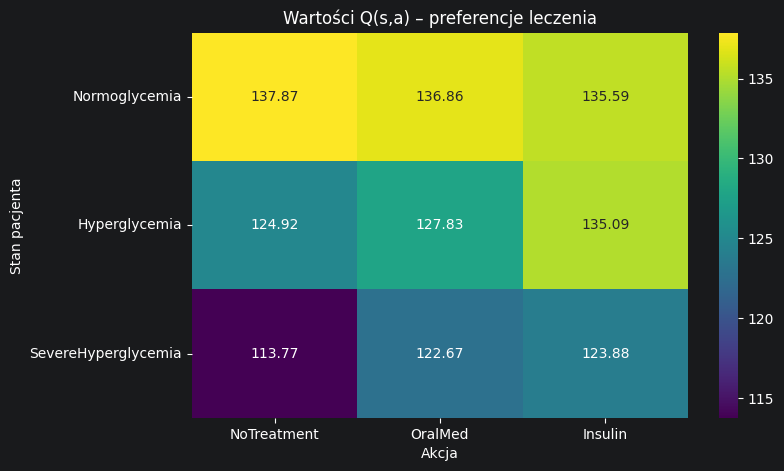

In [40]:
visualize_q_table(q_net, STATES, ACTIONS)


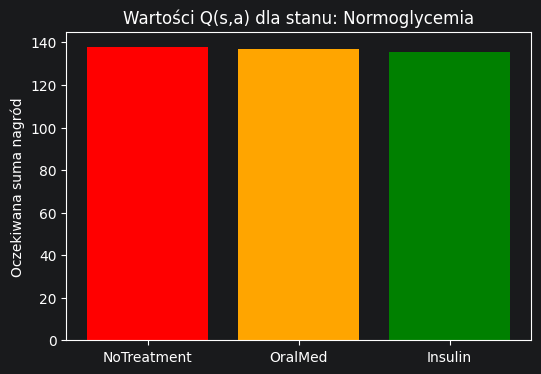

In [42]:
plot_action_q_for_state(q_net, 0, STATES, ACTIONS) # dla stanu "Normoglycemia


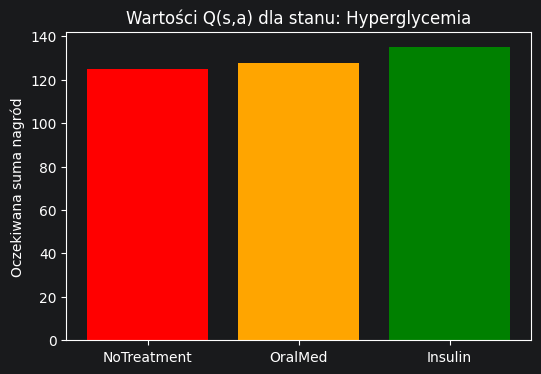

In [43]:
plot_action_q_for_state(q_net, 1, STATES, ACTIONS) # dla stanu "Hyperglycemia


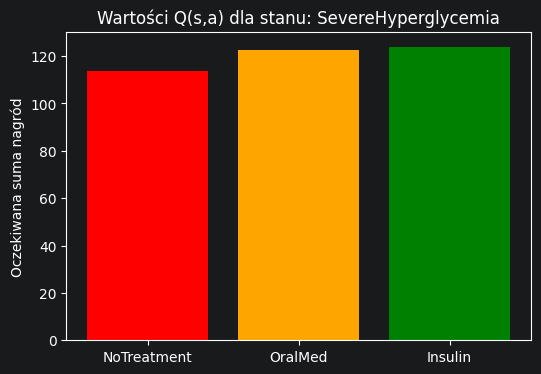

In [41]:
plot_action_q_for_state(q_net, 2, STATES, ACTIONS) # dla stanu "SevereHyperglycemia


### 6.2 Porównanie polityki DQN z polityką bazową (np. „zawsze insulin” lub „zgodna z wytycznymi”)

Użytkownik może chcieć zrozumieć, o ile lepsza jest polityka uczenia się od prostej reguły. Można wygenerować symulację obu polityk i porównać średnie nagrody.


In [39]:
def evaluate_policy(env, policy_func, episodes=100):
    """Ocenia politykę (funkcja mapująca stan -> akcja) na `episodes` epizodach."""
    total_rewards = []
    for _ in range(episodes):
        s = env.reset()
        ep_reward = 0.0
        done = False
        while not done:
            a = policy_func(s)
            result = env.step(a)
            ep_reward += result.reward
            done = result.done
        total_rewards.append(ep_reward)
    return np.mean(total_rewards), np.std(total_rewards)

# Definicja polityki bazowej: zawsze Insulin
def always_insulin_policy(state):
    return A["Insulin"]

# Definicja polityki wyuczonej DQN
def dqn_policy(state):
    vec = encode_state(state, len(STATES))
    q_vals = q_net(np.expand_dims(vec, axis=0), training=False).numpy()[0]
    return np.argmax(q_vals)

mean_baseline, std_baseline = evaluate_policy(env, always_insulin_policy)
mean_dqn, std_dqn = evaluate_policy(env, dqn_policy)

print(f"Polityka 'zawsze insulina': {mean_baseline:.2f} ± {std_baseline:.2f}")
print(f"Polityka DQN: {mean_dqn:.2f} ± {std_dqn:.2f}")
print(f"Zysk z uczenia: {mean_dqn - mean_baseline:.2f}")


Polityka 'zawsze insulina': 92.48 ± 28.48
Polityka DQN: 94.60 ± 24.37
Zysk z uczenia: 2.12


## 7. Próg niepewności decyzji

Polega na tym, że jeśli różnica między najlepszą a drugą najlepszą wartością Q jest mniejsza niż zadany próg (np. 1.0), system powinien sygnalizować niepewność i sugerować konsultację z lekarzem.


In [44]:
def uncertain_decision(q_model, state_idx, threshold=1.0):
    """
    Zwraca akcję oraz flagę niepewności.
    Jeśli różnica Q(best) - Q(second) < threshold -> uncertain = True.
    """
    vec = encode_state(state_idx, len(STATES))
    q_vals = q_model(np.expand_dims(vec, axis=0), training=False).numpy()[0]
    sorted_indices = np.argsort(q_vals)[::-1]
    best_action = sorted_indices[0]
    second_action = sorted_indices[1]
    diff = q_vals[best_action] - q_vals[second_action]
    uncertain = (diff < threshold)
    return best_action, uncertain, diff, q_vals


In [45]:
def recommend_action_with_confidence(q_model, state_name, threshold=1.0):
    state_idx = S[state_name]
    best_action_idx, uncertain, diff, q_vals = uncertain_decision(q_model, state_idx, threshold)
    best_action = ACTIONS[best_action_idx]

    print(f"Stan: {state_name}")
    print(f"Wartości Q: {dict(zip(ACTIONS, q_vals))}")
    print(f"Rekomendowana akcja: {best_action} (różnica do drugiej najlepszej: {diff:.3f})")
    if uncertain:
        print("⚠️ **DECYZJA NIEPEWNA** ⚠️ Różnica poniżej progu. Zalecana konsultacja z lekarzem.")
    else:
        print("✓ Decyzja pewna – można zrealizować.")
    return best_action_idx, uncertain


In [46]:
# Przykład użycia
print("\n--- Test progu niepewności (próg = 1.0) ---")
for state in STATES:
    recommend_action_with_confidence(q_net, state, threshold=1.0)
    print()



--- Test progu niepewności (próg = 1.0) ---
Stan: Normoglycemia
Wartości Q: {'NoTreatment': np.float32(137.86588), 'OralMed': np.float32(136.85759), 'Insulin': np.float32(135.58696)}
Rekomendowana akcja: NoTreatment (różnica do drugiej najlepszej: 1.008)
✓ Decyzja pewna – można zrealizować.

Stan: Hyperglycemia
Wartości Q: {'NoTreatment': np.float32(124.91794), 'OralMed': np.float32(127.82647), 'Insulin': np.float32(135.08832)}
Rekomendowana akcja: Insulin (różnica do drugiej najlepszej: 7.262)
✓ Decyzja pewna – można zrealizować.

Stan: SevereHyperglycemia
Wartości Q: {'NoTreatment': np.float32(113.7689), 'OralMed': np.float32(122.67347), 'Insulin': np.float32(123.88037)}
Rekomendowana akcja: Insulin (różnica do drugiej najlepszej: 1.207)
✓ Decyzja pewna – można zrealizować.

